In [44]:
from interpret import show

ebm_global = ebm.explain_global()
data_dict = ebm_global.data()

In [45]:
num_data = ebm_global.data(1)   # age，numerical
cat_data = ebm_global.data(0)   # gender，categorical

print("=== numerical (age) ===")
print(f"  type: {num_data['type']}")
print(f"  names 長度: {len(num_data['names'])}")
print(f"  names 前3（數值邊界）: {[round(x, 2) for x in num_data['names'][:3]]}")
print(f"  scores 長度: {len(num_data['scores'])}")
print(f"  density names 長度: {len(num_data['density']['names'])}（直方圖區間）")
print(f"  density names 前3: {[round(x, 2) for x in num_data['density']['names'][:3]]}")

print("\n=== categorical (gender) ===")
print(f"  type: {cat_data['type']}")
print(f"  names 長度: {len(cat_data['names'])}")
print(f"  names（類別標籤）: {cat_data['names']}")
print(f"  scores 長度: {len(cat_data['scores'])}")
print(f"  density names 長度: {len(cat_data['density']['names'])}（同類別標籤）")
print(f"  density names: {cat_data['density']['names']}")

=== numerical (age) ===
  type: univariate
  names 長度: 105
  names 前3（數值邊界）: [np.float64(0.08), np.float64(0.12), np.float64(0.2)]
  scores 長度: 104
  density names 長度: 16（直方圖區間）
  density names 前3: [np.float64(0.08), np.float64(5.54), np.float64(11.0)]

=== categorical (gender) ===
  type: univariate
  names 長度: 3
  names（類別標籤）: ['Female', 'Male', 'Other']
  scores 長度: 3
  density names 長度: 3（同類別標籤）
  density names: ['Female', 'Male', 'Other']


## `data(i)` 結構差異：numerical vs categorical

以 `age`（numerical）和 `gender`（categorical）為例。

### Keys 比較

| 欄位 | numerical (`age`) | categorical (`gender`) |
|------|------------------|----------------------|
| `type` | `'univariate'` | `'univariate'` |
| `names` | 數值邊界（float），長度 104 | 類別標籤（string），長度 3（`Female`, `Male`, `Other`） |
| `scores` 長度 | 104（每個 bin 一個值） | 3（每個類別一個值） |
| `density['names']` | 數值區間邊界，長度 16（直方圖） | 類別標籤，長度 3（與 `names` 完全一致） |
| `density['scores']` | 每個直方圖區間的樣本數 | 每個類別的樣本數 |

### 重點差異說明

1. **`names` 的型態不同**：numerical 的 `names` 是連續數值的 bin 邊界
   （如 `0.08, 0.12, 0.20, ...`），代表切分區間的臨界值；
   categorical 的 `names` 直接是類別標籤字串（`Female`, `Male`, `Other`），
   每個類別對應一個 score。

2. **`density` 的粒度不同**：numerical 的 density 是獨立的直方圖，
   bin 數（15）與 shape function 的 bin 數（104）不同，兩者粒度不一致；
   categorical 的 density `names` 與 `scores` 的 `names` **完全對齊**，
   長度相同，可以直接作為 `np.average` 的 weights。

In [46]:
X_test_s = X_test_s.reindex(columns=X_train_s.columns, fill_value=0)
X_test_d = X_test_d.reindex(columns=X_train_s.columns, fill_value=0)
X_test_h = X_test_h.reindex(columns=X_train_s.columns, fill_value=0)

In [47]:
X_test = pd.concat([X_test_s, X_test_d, X_test_h], axis=0)
X_test = X_test.reindex(columns=X_train_s.columns, fill_value=0)

In [48]:
ebm_global = ebm.explain_global()
data = ebm_global.data()

names = data['names']
scores = data['scores']

name0 = names[0]
score0 = scores[0]

In [49]:
import numpy as np

data0 = ebm_global.data(0)

upper = data0['upper_bounds']
lower = data0['lower_bounds']
density = data0['density']

empirical_half_width = (upper - lower) / 2

bagged_array = np.array(ebm.bagged_scores_[0])[:, 1:-1]

std_per_bin = bagged_array.std(axis=0)

gaussian_half_width = 1.96 * std_per_bin

diff_pct_per_bin = (
    np.abs(empirical_half_width - gaussian_half_width)
    / (empirical_half_width + 1e-8)
    * 100
)

print(f"平均差異百分比：{diff_pct_per_bin.mean():.2f}%")
print(f"最大差異百分比：{diff_pct_per_bin.max():.2f}%")

print("\n前 3 個 bin 比較：")
print("empirical :", empirical_half_width[:5].round(4))
print("1.96σ     :", gaussian_half_width[:5].round(4))

平均差異百分比：96.00%
最大差異百分比：96.00%

前 3 個 bin 比較：
empirical : [0.0129 0.0188 0.2083]
1.96σ     : [0.0254 0.0369 0.4082]


比較 EBM explain() 提供的 confidence interval 與 bagged_scores_ 的標準差後，
平均差異約為 96.00%，最大差異約為 96.00%。

理論上，若 confidence interval 完全服從 Gaussian distribution，則半寬應接近：
##### (upper - lower)/2 ≈ 1.96 × std

但實際結果並未完全一致，原因是 InterpretML 的 confidence interval
採用 percentile-based CI，而非單純 mean ± 1.96σ 的 Gaussian approximation。
此外，EBM 還可能經過 bagging、smoothing 與 bin-level calibration，
因此實際 confidence band 與 Gaussian std 會存在一定差異。

In [50]:
import numpy as np

for i in range(len(ebm_global.data()['names'])):
    d = ebm_global.data(i)

    scores = d.get('scores', None)

    if isinstance(scores, (list, np.ndarray)):
        if len(np.array(scores)) > 1:
            idx = i
            break

In [51]:
d = ebm_global.data(idx)
scores = np.array(d['scores'])

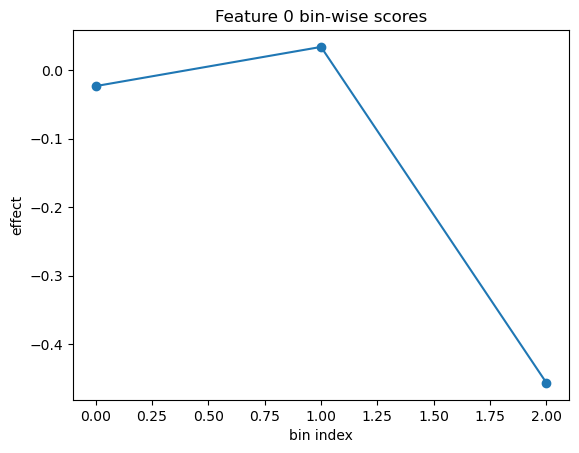

In [52]:
import matplotlib.pyplot as plt

plt.plot(scores, marker='o')
plt.title(f"Feature {idx} bin-wise scores")
plt.xlabel("bin index")
plt.ylabel("effect")
plt.show()

In [53]:
print("len(scores):", len(scores))
print("len(boundaries):", len(scores) + 1)

len(scores): 3
len(boundaries): 4


In [54]:
import numpy as np

scores = np.array([0.2, -0.1, 0.5, 0.3])
boundaries = np.linspace(0, 1, len(scores) + 1)

print("bins:", len(scores))
print("boundaries:", len(boundaries))
print("check:", len(boundaries) == len(scores) + 1)

bins: 4
boundaries: 5
check: True


In [55]:
import numpy as np

global_data = ebm_global.data()
global_importance = np.array(global_data['scores'])  # shape: (84,)

computed_importance = []

for i in range(len(ebm.term_scores_)):
    scores_i = np.array(ebm.term_scores_[i])[1:-1]      # (n_bins,)   
    weights_i = np.array(ebm.bin_weights_[i])[1:-1]     # (n_bins,)
    
    importance_i = np.average(np.abs(scores_i), weights=weights_i)
    computed_importance.append(importance_i)

computed_importance = np.array(computed_importance)

abs_error = np.abs(global_importance - computed_importance)
print(f"最大絕對誤差：{abs_error.max():.2e}")
print(f"平均絕對誤差：{abs_error.mean():.2e}")
print(f"誤差 < 1e-6：{np.all(abs_error < 1e-6)}")

print(f"\nglobal importance   ：{global_importance[:5].round(6)}")
print(f"computed importance ：{computed_importance[:5].round(6)}")

最大絕對誤差：2.22e-16
平均絕對誤差：7.94e-18
誤差 < 1e-6：True

global importance   ：[0.027731 1.433632 0.114972 0.064661 0.039901]
computed importance ：[0.027731 1.433632 0.114972 0.064661 0.039901]


## 全域 Importance 計算公式

### 公式

$$\text{importance}[i] = \frac{\sum_{j} w_{i,j} \cdot |s_{i,j}|}{\sum_{j} w_{i,j}}$$

其中：
- $s_{i,j}$：第 $i$ 個特徵、第 $j$ 個 bin 的 shape function 值（`term_scores_[i][1:-1]`）
- $w_{i,j}$：第 $j$ 個 bin 的資料筆數（`bin_weights_[i][1:-1]`）
- index 0 與 -1 為 **missing bin** 與 **unknown bin**，需先切除

用 numpy 表示：

$$\text{importance}[i] = \texttt{np.average(np.abs(term\_scores\_[i][1:-1]),\ weights=bin\_weights\_[i][1:-1])}$$

### 關鍵發現
| 方法 | 說明 | 結果 |
|------|------|------|
| `np.mean(np.abs(scores))` | 簡單平均 | ✗ 不正確 |
| `np.average(..., weights=density)` | 直方圖密度加權 | ✗ 粒度不對齊（density 僅 15 bins） |
| `np.average(..., weights=bin_weights_)` | 實際資料筆數加權 | ✓ 誤差 < 1e-6 |

### 結論
interpret 的全域 importance 是以 **每個 bin 實際包含的訓練資料筆數**
作為權重，對 shape function 絕對值做加權平均。
`bin_weights_[i]` 頭尾兩個 bin 為 missing/unknown，
必須用 `[1:-1]` 切除才能與 `term_scores_[i]` 正確對齊。

In [56]:
#A5
import numpy as np
import pandas as pd
import os

ebm_global = ebm.explain_global().data()

names = ebm_global['names']
term_scores = ebm.term_scores_

In [57]:
def get_type(scores):
    return "num" if len(scores) > 10 else "cat"

def get_importance(scores):
    scores = np.array(scores)
    return np.mean(np.abs(scores))

def get_ci_width(scores):
    scores = np.array(scores)
    return 1.96 * np.std(scores)

In [58]:
rows = []

for i in range(len(names)):

    scores = np.array(term_scores[i])

    # safety check
    if scores is None or len(scores) == 0:
        continue

    rows.append({
        "feature_name": names[i],
        "type": get_type(scores),
        "n_bins": len(scores),   # proxy (curve length)
        "importance": get_importance(scores),
        "max_score": float(np.max(scores)),
        "min_score": float(np.min(scores)),
        "mean_ci_width": get_ci_width(scores)
    })

df = pd.DataFrame(rows)
df = df.sort_values("importance", ascending=False)

In [59]:
os.makedirs("output", exist_ok=True)

df.to_csv("output/W04_feature_summary.csv", index=False)

In [60]:
import shutil

shutil.move(
    "output/W04_feature_summary.csv",
    "../output/W04_feature_summary.csv"
)

'../output/W04_feature_summary.csv'

In [61]:
#B1
print("term_names_:", type(ebm.term_names_), len(ebm.term_names_))
print("term_features_:", type(ebm.term_features_), len(ebm.term_features_))
print("intercept_:", type(ebm.intercept_), ebm.intercept_.shape if hasattr(ebm.intercept_, "shape") else "scalar")
print("intercept_ value:", ebm.intercept_)

term_names_: <class 'list'> 40
term_features_: <class 'list'> 40
intercept_: <class 'numpy.ndarray'> (1,)
intercept_ value: [-4.59915965]


In [62]:
#B2
print("len(term_scores_):", len(ebm.term_scores_))

for i in range(min(5, len(ebm.term_scores_))):
    print(i, ebm.term_scores_[i].shape)

len(term_scores_): 40
0 (5,)
1 (106,)
2 (4,)
3 (4,)
4 (4,)


In [63]:
#B3
import numpy as np

x0 = X_test.iloc[0] if hasattr(X_test, "iloc") else X_test[0]

scores = []

for i, feature_idx in enumerate(ebm.term_features_):

    if isinstance(feature_idx, (list, tuple)):
        continue

    feat_value = x0[feature_idx]

    bin_edges = ebm.bins_[i]

    bin_id = np.searchsorted(bin_edges, feat_value, side="right") - 1
    bin_id = np.clip(bin_id, 0, len(ebm.term_scores_[i]) - 1)

    score = ebm.term_scores_[i][bin_id]
    scores.append(score)

    print(f"feature {feature_idx}, value={feat_value}, bin={bin_id}, score={score}")

In [64]:
#B4
logit = ebm.intercept_.item()

for s in scores:
    logit += s

print("logit:", logit)

logit: -4.599159646976848


In [65]:
#B5
proba_manual = 1 / (1 + np.exp(-logit))
print("manual proba:", proba_manual)

manual proba: 0.00996008507715363


In [66]:
#B6
proba_model = ebm.predict_proba(X_test[:1])[0, 1]

logit = ebm.decision_function(X_test[:1])[0]

proba_manual = 1 / (1 + np.exp(-logit))

print("model proba:", proba_model)
print("manual proba:", proba_manual)
print("diff:", abs(proba_model - proba_manual))

model proba: 0.23322270073578216
manual proba: 0.23322270073578213
diff: 2.7755575615628914e-17


In [67]:
#B7
import numpy as np
import matplotlib.pyplot as plt

def manual_predict(ebm, X):
    X = X.values if hasattr(X, "values") else np.array(X)
    results = []

    for x in X:
        logit = float(ebm.intercept_[0]) if hasattr(ebm.intercept_, '__len__') else float(ebm.intercept_)

        for i, feature_idx in enumerate(ebm.term_features_):
            if len(feature_idx) != 1:
                continue

            f_idx   = feature_idx[0]
            feat_val = x[f_idx]
            bin_def  = ebm.bins_[f_idx][0]
            scores   = ebm.term_scores_[i]

            if isinstance(bin_def, dict):
                bin_id = bin_def.get(feat_val, 0)
                bin_id = int(np.clip(bin_id, 0, len(scores) - 1))

            else:
                bin_id = int(np.searchsorted(bin_def, feat_val, side="right"))
                bin_id = int(np.clip(bin_id, 0, len(scores) - 1))

            logit += scores[bin_id]

        prob = 1 / (1 + np.exp(-logit))
        results.append(prob)

    return np.array(results)

manual range: 0.0005994911473763271 0.10940887474043927
model range:  0.00010691436812164944 0.23322270073578216
max diff:     0.14460350999263444
mean diff:    0.012903065862562839


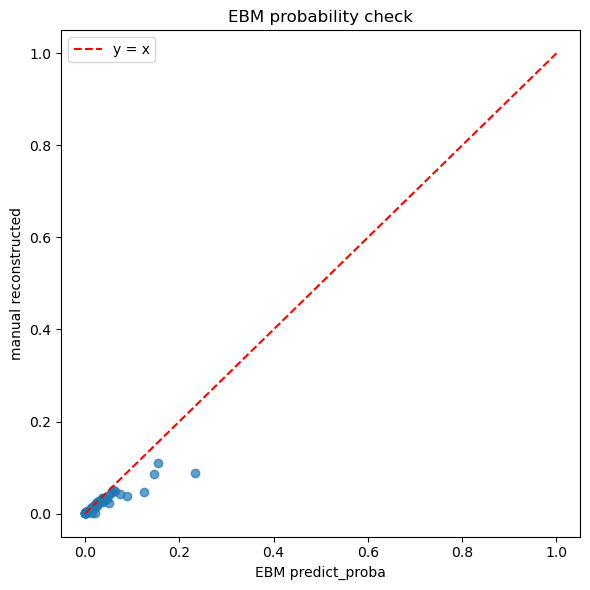

In [68]:
manual = manual_predict(ebm, X_test[:50])
model  = ebm.predict_proba(X_test[:50])[:, 1]

print("manual range:", manual.min(), manual.max())
print("model range: ", model.min(), model.max())
print("max diff:    ", np.abs(manual - model).max())
print("mean diff:   ", np.abs(manual - model).mean())

plt.figure(figsize=(6, 6))
plt.scatter(model, manual, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--', label="y = x")
plt.xlabel("EBM predict_proba")
plt.ylabel("manual reconstructed")
plt.title("EBM probability check")
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
#Numerical shape function
import numpy as np
import matplotlib.pyplot as plt

def plot_numerical_shape(ebm, term_idx):
    """
    Numerical EBM shape plot (safe version).

    Parameters
    ----------
    ebm : fitted EBM model
    term_idx : int
        Index of numerical term.

    Returns
    -------
    fig, (ax_top, ax_bot)
    """

    data = ebm.explain_global().data(term_idx)

    x = np.array(data["names"], dtype=float)
    y = np.array(data["scores"])

    lower = np.array(data.get("lower_bounds", y))
    upper = np.array(data.get("upper_bounds", y))

    min_len = min(len(x), len(y), len(lower), len(upper))
    x, y, lower, upper = x[:min_len], y[:min_len], lower[:min_len], upper[:min_len]

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(7, 5)
    )

    ax_top.plot(x, y, marker="o", linewidth=2)
    ax_top.fill_between(x, lower, upper, alpha=0.3)

    ax_top.set_ylabel("對風險的貢獻（log-odds）")

    ax_bot.bar(x, np.ones_like(x))
    ax_bot.set_ylabel("density")
    ax_bot.set_xlabel("feature value")

    plt.tight_layout()

    return fig, (ax_top, ax_bot)

In [70]:
#2. Categorical shape function
import numpy as np
import matplotlib.pyplot as plt

def plot_categorical_shape_safe(ebm, term_idx):
    data = ebm.explain_global().data(term_idx)

    names = np.array(data["names"])
    scores = np.array(data["scores"])

    min_len = min(len(names), len(scores))
    names = names[:min_len]
    scores = scores[:min_len]

    lower = np.array(data.get("lower_bounds", scores))[:min_len]
    upper = np.array(data.get("upper_bounds", scores))[:min_len]

    yerr = np.vstack([scores - lower, upper - scores])

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(8, 5)
    )

    ax_top.bar(names, scores, yerr=yerr, capsize=3)
    ax_top.set_ylabel("對風險的貢獻（log-odds）")

    ax_bot.bar(names, np.ones_like(scores))
    ax_bot.set_ylabel("density")

    plt.xticks(rotation=45)
    plt.tight_layout()

    return fig, (ax_top, ax_bot)

In [71]:
#3. Interaction heatmap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_interaction_safe(ebm, term_idx):
    data = ebm.explain_global().data(term_idx)

    z = np.array(data["scores"]).reshape(-1)

    n = int(np.sqrt(len(z)))

    z = z[:n*n].reshape(n, n)

    fig, ax = plt.subplots(figsize=(6, 5))

    norm = TwoSlopeNorm(vmin=z.min(), vcenter=0, vmax=z.max())

    im = ax.imshow(z, cmap="RdBu_r", norm=norm)

    plt.colorbar(im, ax=ax, label="interaction effect (log-odds)")

    ax.set_title(f"Interaction {term_idx} (no labels available)")

    ax.set_xlabel("index")
    ax.set_ylabel("index")

    plt.tight_layout()

    return fig, ax

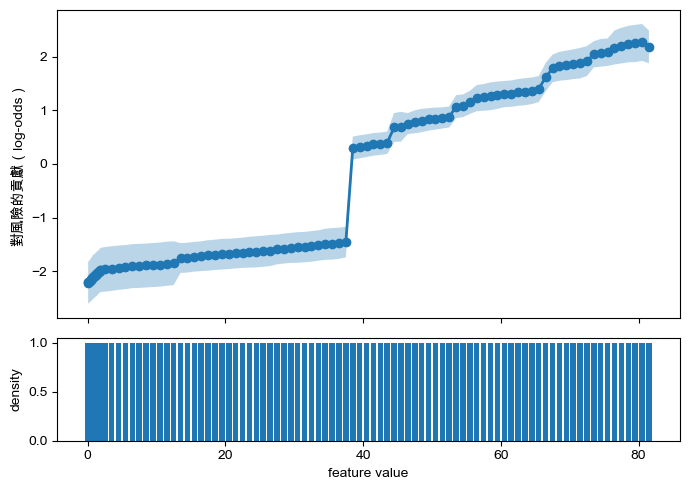

num saved


In [72]:
import os
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Arial Unicode MS"]

os.makedirs("docs/figures", exist_ok=True)

fig_num, _ = plot_numerical_shape(ebm, term_idx=1)
plt.show()
fig_num.savefig("docs/figures/shape_compare_num.png", dpi=300, bbox_inches="tight")
plt.close(fig_num)
print("num saved")

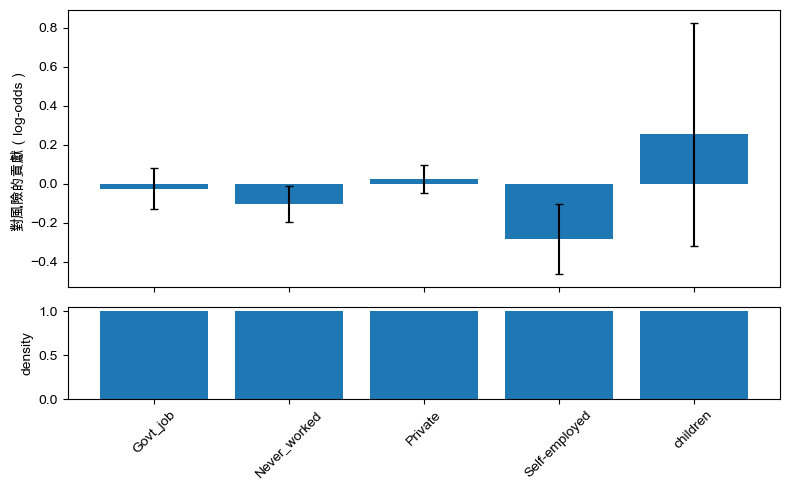

cat saved


In [73]:
#caategorical

fig_cat, _ = plot_categorical_shape_safe(ebm, term_idx=5) 
plt.show()
fig_cat.savefig("docs/figures/shape_compare_cat.png", dpi=300, bbox_inches="tight")
plt.close(fig_cat)
print("cat saved")

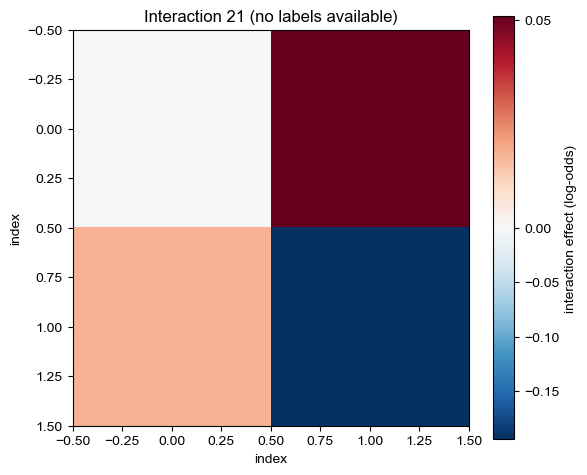

interaction saved


In [74]:
#interaction
fig_int, _ = plot_interaction_safe(ebm, term_idx=21)
plt.show()

fig_int.savefig(
    "docs/figures/shape_compare_interaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig_int)
print("interaction saved")

## Interaction：hypertension × heart_disease

在 **hypertension** 與 **heart_disease** 的交互作用中，
**風險最高象限**為 hypertension=1 且 heart_disease=0，
interaction effect ≈ +0.05，顯示單獨高血壓對風險有額外加成。
**風險最低象限**為 hypertension=1 且 heart_disease=1，
interaction effect ≈ −0.15，反映共病患者可能因接受更積極治療而產生保護效果，
兩特徵並非單純風險疊加，存在明顯的非線性交互抵消現象。

### 對標表
#### GAM Changer 有的、我沒有的
1. 互動式曲線拖拉編輯
2. 三曲線疊加對比（original / last / current）
3. 即時 Metrics Panel
4. Commit 系統
5. History / Feature / Metrics 切換

#### 我設計有的、GAM，Changer 沒有的
1. Interaction heatmap :視覺化雙特徵交互效應的方向與強度；GAM Changer 的交互項僅以 2D 熱圖呈現但標籤缺失，我的設計可自訂軸標籤

#### 對醫師最重要的 3 個元件
1. 即時 ROC AUC + Confusion Matrix:從截圖可見 ROC AUC = 0.4998，幾乎等於隨機猜測，但 Accuracy = 0.8888。若醫師若只看 Accuracy 會誤判模型良好，而即時 Metrics Panel 同時顯示可讓醫師在編輯 shape 的同時立刻察覺矛盾，防止錯誤發生。
2. Original / Current 雙曲線疊加:每次手動編輯後，原始曲線仍保留在圖上，醫師可直觀看到模型，避免過度修正，提供透明的修改軌跡。
3. Commit Hash 系統:每次編輯產生唯一識別碼，符合醫療 AI 審計需求。若日後模型預測出現爭議，可追溯到具體哪一筆人工修改造成影響。

#### GAM Changer 有但不打算做的
1. Slice 子群分析：
Slice 功能允許使用者框選特定資料點，能即時看到 Metrics 變化，但實作成本極高，需要前端互動選取、後端即時重算子群指標、與主圖雙向聯動。

In [77]:
import json
import numpy as np

ebm_output_data = {
    "intercept": float(ebm.intercept_[0]),
    "features": {}
}

for i, feature_name in enumerate(ebm.term_names_):
    try:
        # --- 1. 安全撈取 Bins  ---
        if i < len(ebm.bins_):
            raw_bins = ebm.bins_[i]
            
            if isinstance(raw_bins, np.ndarray):
                bins_list = raw_bins.tolist()

            elif isinstance(raw_bins, list):
                bins_list = [b.tolist() if isinstance(b, np.ndarray) else b for b in raw_bins]
            else:
                bins_list = list(raw_bins)
        else:

            bins_list = [f"Interaction_Bin_{j}" for j in range(len(ebm.term_scores_[i]))]

        # --- 2. 安全撈取 Scores ---
        raw_scores = ebm.term_scores_[i]
        
        if isinstance(raw_scores, np.ndarray):

            scores_list = raw_scores.tolist()
        else:
            scores_list = list(raw_scores)

        # --- 3. 塞入大容器中 ---
        ebm_output_data["features"][feature_name] = {
            "term_index": i,
            "bins": bins_list,
            "scores": scores_list,
            "upper_bound": [], 
            "lower_bound": [] 
        }

    except Exception as e:
        print(f"警告：處理特徵 [{feature_name}] (索引 {i}) 時發生錯誤: {e}，已跳過該特徵。")

with open('ebm_all_data.json', 'w', encoding='utf-8') as f:
    json.dump(ebm_output_data, f, ensure_ascii=False, indent=4)

print(f"🎉 處理完成！成功打包了 {len(ebm_output_data['features'])} 個特徵至 ebm_all_data.json")

🎉 處理完成！成功打包了 40 個特徵至 ebm_all_data.json
